# HR Comparison Plots (Paper-ready)
This notebook loads summary JSONs and plots HR vs cache size for selected methods.


In [1]:
from __future__ import annotations
import json
import re
from pathlib import Path
import matplotlib.pyplot as plt

RESULTS_ROOT = Path('results')
OUT_DIR = Path('results/figures')
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Select datasets and methods to compare
DATASETS = {
    'wiki2018': RESULTS_ROOT / 'wiki2018',
    'wikipedia_september_2007': RESULTS_ROOT / 'wikipedia_september_2007',
}

METHODS = {
    'baseline_lru': 'LRU',
    'baseline_lru-k': 'LRU-K',
    'ilnse_xu': 'Xu-IL',
    'gdbt_A2': 'GDBT (A2)',
    'ilnse_A2_full': 'Ours (A2, Full)',
}

STYLE = {
    'baseline_lru': dict(color='#7F7F7F', lw=1.8, ls='--'),
    'baseline_lru-k': dict(color='#A2A2A2', lw=1.8, ls='-.'),
    'ilnse_xu': dict(color='#1f77b4', lw=2.0, ls='-'),
    'gdbt_A2': dict(color='#2ca02c', lw=2.0, ls='-'),
    'ilnse_A2_full': dict(color='#d62728', lw=2.5, ls='-'),
}

def load_latest_summaries(dataset_dir: Path):
    pat = re.compile(r'^(\d{3})_summary_(.+)_(\d+)\.json$')
    records = {}
    for p in dataset_dir.glob('*_summary_*.json'):
        if p.name.endswith('_all_sizes.json'):
            continue
        m = pat.match(p.name)
        if not m:
            continue
        run_id = int(m.group(1))
        model = m.group(2)
        cache = int(m.group(3))
        key = (model, cache)
        cur = records.get(key)
        if cur is None or run_id > cur[0]:
            records[key] = (run_id, json.loads(p.read_text()))
    return records

def build_curves(records):
    caches = sorted({c for _, c in records})
    curves = {}
    for model in METHODS:
        pts = []
        for c in caches:
            entry = records.get((model, c))
            if entry is None:
                continue
            hr = entry[1].get('hit_ratio')
            pts.append((c, hr))
        if pts:
            curves[model] = pts
    return curves


In [2]:
# Diagnostics: verify data availability
for ds_name, ds_dir in DATASETS.items():
    print(f'Dataset {ds_name}:', ds_dir)
    if not ds_dir.exists():
        print('  -> MISSING directory')
        continue
    files = list(ds_dir.glob('*_summary_*.json'))
    print('  summary files:', len(files))
    # show a few file names
    for f in files[:5]:
        print('   -', f.name)
    records = load_latest_summaries(ds_dir)
    print('  latest summaries loaded:', len(records))
    # show available models
    models = sorted({m for (m, _) in records})
    print('  models:', models)
    caches = sorted({c for (_, c) in records})
    print('  cache sizes:', caches)
    print()


Dataset wiki2018: results/wiki2018
  summary files: 129
   - 001_summary_ilnse_A2_fixed_100772.json
   - 001_summary_ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05_all_sizes.json
   - 001_summary_ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05_80617.json
   - 001_summary_baseline_lru_100772.json
   - 001_summary_ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05_100772.json
  latest summaries loaded: 114
  models: ['baseline_lru', 'baseline_lru-k', 'gdbt_A2', 'ilnse_A1_full', 'ilnse_A2_drift_only', 'ilnse_A2_fixed', 'ilnse_A2_full', 'ilnse_A2_guard_no_gate', 'ilnse_A2_guard_no_guard', 'ilnse_A2_guard_no_quality', 'ilnse_A2_guard_only', 'ilnse_A2_guard_precision_only', 'ilnse_A2_guard_qsweep_q0.9_ema0.1_min0.7_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.3_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.5_max1.5_boost0.1_gate0.05', 'ilnse_A2_guard_qsweep_q0.9_ema0.2_min0.7_max1.3_boost0.1_gate0.

Saved: results/figures/hr_curve_variants_wiki2018.pdf and results/figures/hr_curve_variants_wiki2018.png
Saved: results/figures/hr_curve_variants_wikipedia_september_2007.pdf and results/figures/hr_curve_variants_wikipedia_september_2007.png


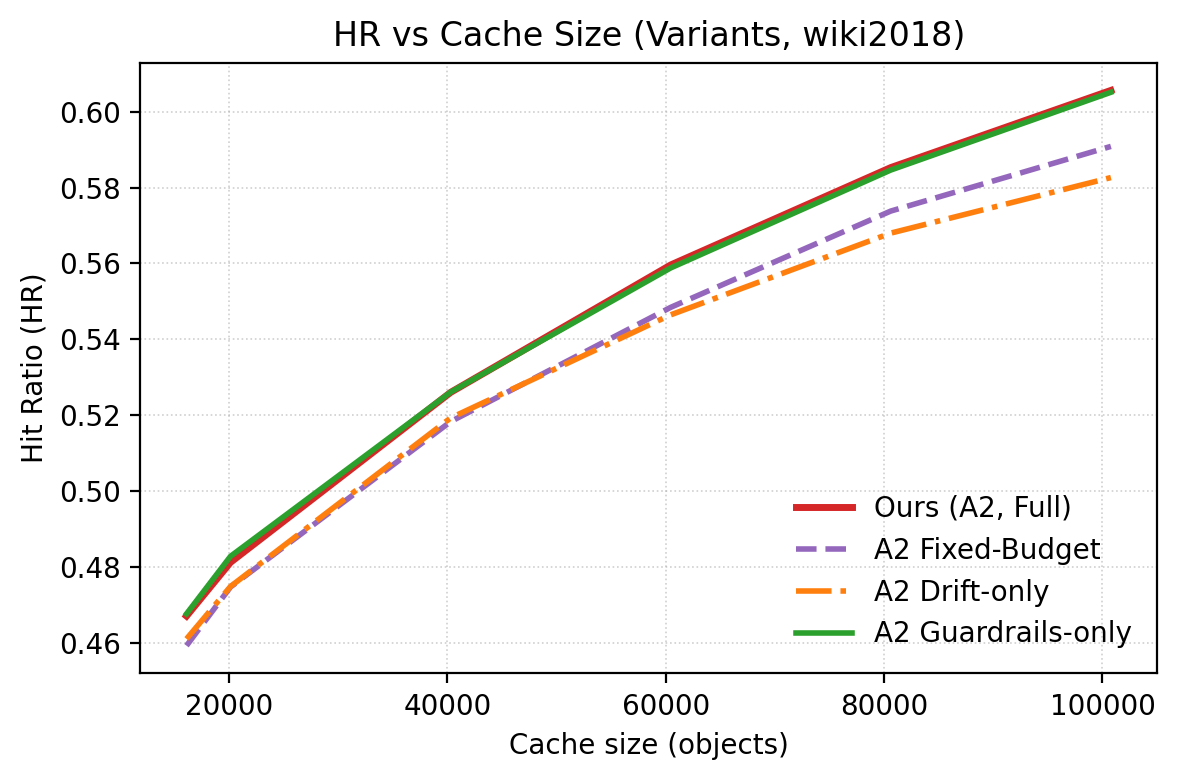

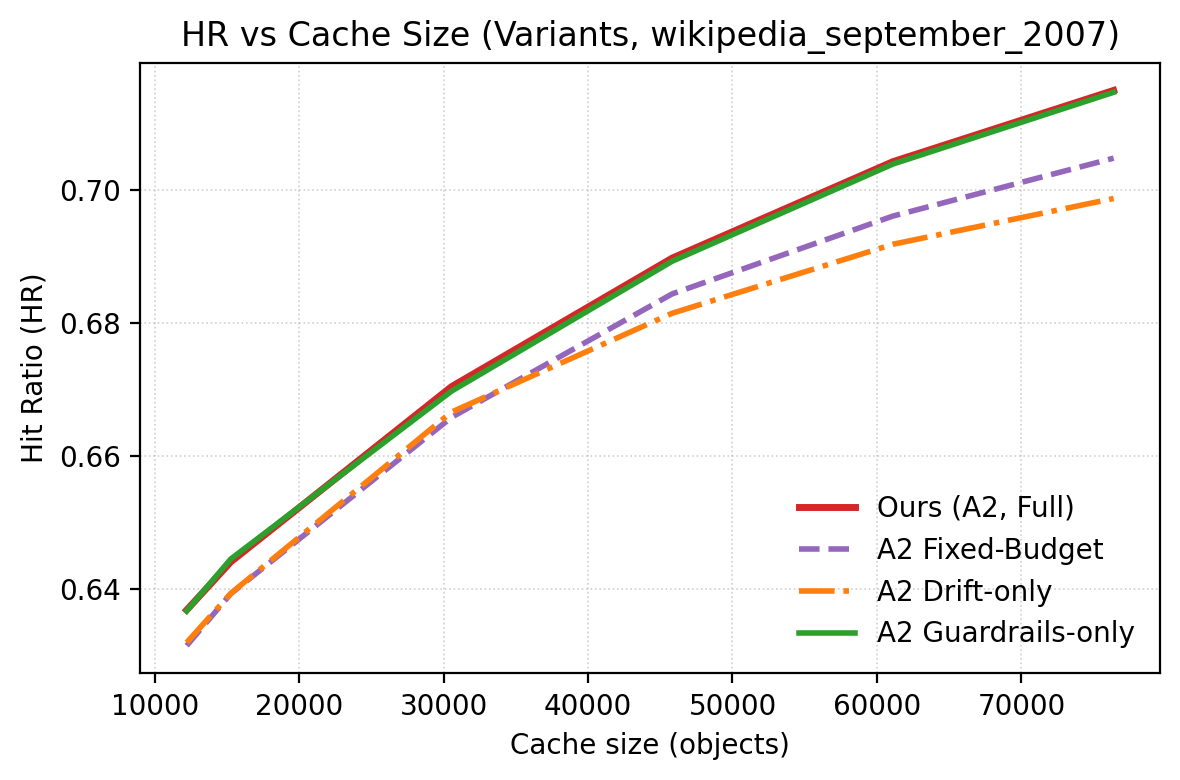

In [3]:
# Comparison focused on ILNSE variants
VARIANT_METHODS = {
    'ilnse_A2_full': 'Ours (A2, Full)',
    'ilnse_A2_fixed': 'A2 Fixed-Budget',
    'ilnse_A2_drift_only': 'A2 Drift-only',
    'ilnse_A2_guard_only': 'A2 Guardrails-only',
    'ilnse_A0_full': 'A0 Full (gap-only)',
}

VARIANT_STYLE = {
    'ilnse_A2_full': dict(color='#d62728', lw=2.5, ls='-'),
    'ilnse_A2_fixed': dict(color='#9467bd', lw=2.0, ls='--'),
    'ilnse_A2_drift_only': dict(color='#ff7f0e', lw=2.0, ls='-.'),
    'ilnse_A2_guard_only': dict(color='#2ca02c', lw=2.0, ls='-'),
    'ilnse_A0_full': dict(color='#1f77b4', lw=2.0, ls=':'),
}

for ds_name, ds_dir in DATASETS.items():
    records = load_latest_summaries(ds_dir)
    caches = sorted({c for (_, c) in records})
    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    for model, label in VARIANT_METHODS.items():
        pts = []
        for c in caches:
            entry = records.get((model, c))
            if entry is None:
                continue
            hr = entry[1].get('hit_ratio')
            pts.append((c, hr))
        if not pts:
            continue
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        ax.plot(xs, ys, label=label, **VARIANT_STYLE.get(model, {}))

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit Ratio (HR)')
    ax.set_title(f'HR vs Cache Size (Variants, {ds_name})')
    ax.grid(True, which='major', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncol=1, loc='lower right')
    fig.tight_layout()
    out_path = OUT_DIR / f'hr_curve_variants_{ds_name}.pdf'
    fig.savefig(out_path)
    out_png = OUT_DIR / f'hr_curve_variants_{ds_name}.png'
    fig.savefig(out_png, dpi=300)
    print('Saved:', out_path, 'and', out_png)


Saved: results/figures/hr_curve_wiki2018.pdf and results/figures/hr_curve_wiki2018.png
Saved: results/figures/hr_curve_wikipedia_september_2007.pdf and results/figures/hr_curve_wikipedia_september_2007.png


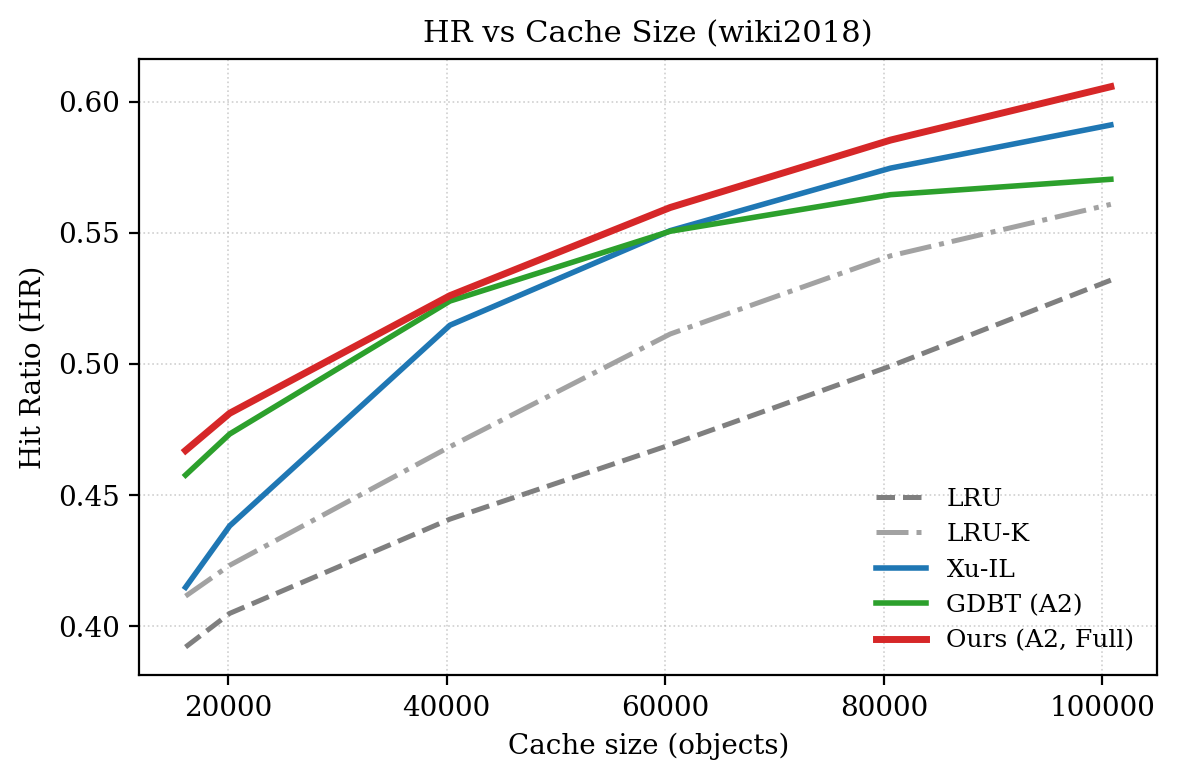

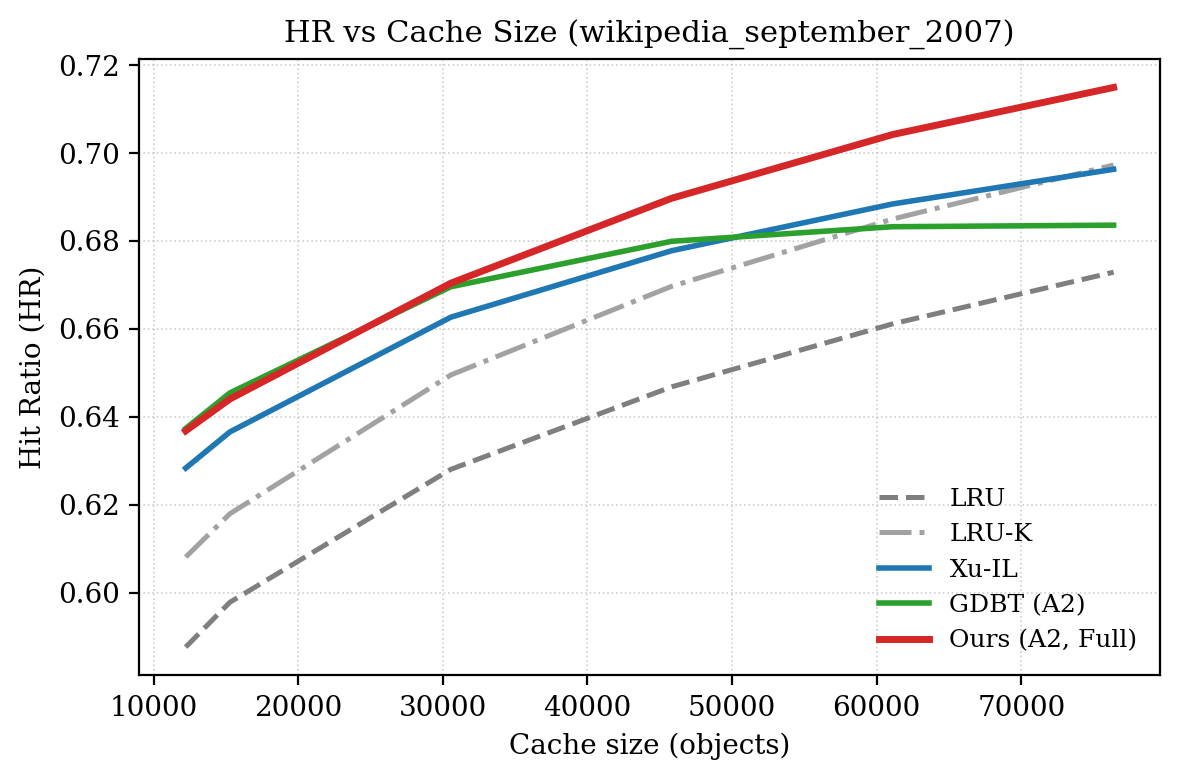

In [4]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 10,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'lines.linewidth': 2.0,
})

for ds_name, ds_dir in DATASETS.items():
    records = load_latest_summaries(ds_dir)
    curves = build_curves(records)

    fig, ax = plt.subplots(figsize=(6.0, 4.0), dpi=200)
    for model, pts in curves.items():
        xs = [p[0] for p in pts]
        ys = [p[1] for p in pts]
        style = STYLE.get(model, {})
        ax.plot(xs, ys, label=METHODS.get(model, model), **style)

    ax.set_xlabel('Cache size (objects)')
    ax.set_ylabel('Hit Ratio (HR)')
    ax.set_title(f'HR vs Cache Size ({ds_name})')
    ax.grid(True, which='major', linestyle=':', linewidth=0.6, alpha=0.6)
    ax.set_axisbelow(True)
    ax.legend(frameon=False, ncol=1, loc='lower right')
    fig.tight_layout()
    out_path = OUT_DIR / f'hr_curve_{ds_name}.pdf'
    fig.savefig(out_path)
    out_png = OUT_DIR / f'hr_curve_{ds_name}.png'
    fig.savefig(out_png, dpi=300)
    print('Saved:', out_path, 'and', out_png)
